## Prepare

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
import plotly.graph_objects as go
import warnings

data_path = "DataSet/AAPL.csv"


In [2]:
panel_df = pd.read_csv(data_path, parse_dates=["Date"])
panel_df["Date"] = pd.to_datetime(panel_df["Date"]).dt.normalize()

panel_df["IV"] = (panel_df["Call_imp_vol"] + panel_df["Put_imp_vol"]) / 2
panel_df["VRP"] = panel_df["IV"] - panel_df["RV"]
panel_df["VRP_mean"] = panel_df["VRP"].rolling(20, min_periods=1).mean()
panel_df["VRP_std"] = panel_df["VRP"].rolling(20, min_periods=1).std()

panel_df = panel_df.dropna(subset=["VRP_std", "IV", "RV"]).reset_index(drop=True)

underlying_df = panel_df.copy()
underlying_df["Close"] = underlying_df["Stock_Close"]

date_list = underlying_df["Date"].dt.strftime("%Y-%m-%d").tolist()
n_days = len(date_list)
print("First trading date:", date_list[0] if date_list else None)

close_prices = underlying_df["Close"].values
underlying_returns = np.diff(close_prices) / close_prices[:-1]
underlying_returns = np.insert(underlying_returns, 0, 0.0)
cum_underlying = np.cumprod(1 + underlying_returns) - 1

First trading date: 2024-05-02


## Agent_DDH — set **VRP_ENTRY_K** and **VRP_CLOSE_THRESHOLD** in the next section (× rolling VRP std)


In [3]:
from Agent_DDH_Class import run_agent_ddh_backtest


## Start Back_test

In [9]:
# Entry: long if VRP < mean - k·std, short if VRP > mean + k·std (Agent_DDH.build_position)
# Exit: VRP mean-reversion at close_threshold·std (Agent_DDH.should_exit)
VRP_ENTRY_K = 1.0
VRP_CLOSE_THRESHOLD = 0.0
RUN_PARAM_SWEEP = False
K_GRID = [0.5, 1.0, 1.5]
CLOSE_GRID = [0.5, 1.0]

if RUN_PARAM_SWEEP:
    from IPython.display import display

    sweep_rows = []
    for k in K_GRID:
        for cth in CLOSE_GRID:
            _, sm = run_agent_ddh_backtest(panel_df, vrp_entry_k=k, vrp_close_threshold=cth)
            sweep_rows.append({"vrp_k": k, "close_th": cth, **sm})
    display(pd.DataFrame(sweep_rows))

result_df, backtest_summary = run_agent_ddh_backtest(
    panel_df,
    vrp_entry_k=VRP_ENTRY_K,
    vrp_close_threshold=VRP_CLOSE_THRESHOLD,
)

print("=== Backtest summary (Agent_DDH) ===")
print(pd.Series(backtest_summary))


=== Backtest summary (Agent_DDH) ===
vrp_entry_k                    1.000000
vrp_close_threshold            0.000000
n_trades                      37.000000
prob_win_trade                 0.621622
prob_win_daily                 0.331237
kelly_binary                   0.286428
kelly_continuous_daily         2.344923
win_loss_ratio_R               1.128837
mean_daily_return              0.000766
std_daily_return               0.018074
final_nav                 133429.470046
dtype: float64


In [10]:
# Align legacy variable names for plots / log cell below
from pathlib import Path
import numpy as np
import pandas as pd

date_idx = pd.to_datetime(result_df["Date"])
n = len(result_df)

nav_ddh = (
    result_df["NAV"].values.astype(float)
    if "NAV" in result_df.columns
    else result_df["Equity"].values.astype(float)
)
nav_straddle = nav_ddh.copy()

ret_ddh = np.where(np.isfinite(result_df["DailyReturn"].values), result_df["DailyReturn"].values, 0.0)
ret_straddle = ret_ddh.copy()
cum_ddh = np.cumprod(1.0 + ret_ddh) - 1.0
cum_straddle = cum_ddh.copy()

gamma_ddh = result_df["Gamma"].values.astype(float)
delta_ddh = result_df["NetDelta"].values.astype(float)
vega_ddh = result_df["Vega"].values.astype(float)
theta_ddh = result_df["Theta"].values.astype(float)
vanna_ddh = result_df["Vanna"].values.astype(float)
volga_ddh = result_df["Volga"].values.astype(float)
opt_ddh = np.where(np.abs(result_df["CallNum"].values) > 1e-12, 2.0 * np.abs(result_df["CallNum"].values), 0.0)
und_ddh = result_df["HedgeShares"].values.astype(float)
event_ddh = result_df["TradeEvent"].astype(str).tolist()
call_sym_ddh = result_df["CallSymbol"].astype(str).tolist()
exit_call_sym_ddh = result_df["ExitCallSymbol"].astype(str).tolist()
rolled_ddh = result_df["Rolled"].values
balance_ddh = np.full(n, np.nan)
option_value_ddh = np.where(np.isfinite(result_df["PortfolioMTM"]), result_df["PortfolioMTM"], 0.0).astype(float)

nav_ddh_arr = nav_ddh
nav_straddle_arr = nav_straddle

# Straddle columns (same run — duplicate for old plotting code)
gamma_straddle = gamma_ddh.copy()
delta_straddle = result_df["NetDelta"].values.astype(float)
vega_straddle = vega_ddh.copy()
theta_straddle = theta_ddh.copy()
vanna_straddle = vanna_ddh.copy()
volga_straddle = volga_ddh.copy()
opt_straddle = opt_ddh.copy()
und_straddle = np.zeros(n)
event_straddle = event_ddh.copy()
call_sym_straddle = call_sym_ddh.copy()
exit_call_sym_straddle = exit_call_sym_ddh.copy()
rolled_straddle = rolled_ddh.copy()
balance_straddle = balance_ddh.copy()
option_value_straddle = option_value_ddh.copy()

dates_rehedge_ddh = pd.to_datetime(
    result_df.loc[result_df["RehedgeDay"], "Date"]
).tolist()
_te = result_df["TradeEvent"].astype(str)
dates_long_ddh = pd.to_datetime(date_idx[_te == "enter_long"]).tolist()
dates_short_ddh = pd.to_datetime(date_idx[_te == "enter_short"]).tolist()
_mexit = _te.str.startswith("exit")
dates_close_ddh = pd.to_datetime(date_idx[_mexit]).tolist()
vrp_plot_threshold = float(backtest_summary.get("vrp_entry_k", 1.0))

result_ddh = result_df.copy()
result_ddh["NAV"] = result_df["NAV"] if "NAV" in result_df.columns else result_df["Equity"]
result_ddh["Return"] = ret_ddh
result_ddh["CumReturn"] = cum_ddh
result_ddh["Delta"] = delta_ddh
result_ddh["Gamma"] = gamma_ddh
result_ddh["Vega"] = vega_ddh
result_ddh["Theta"] = theta_ddh
result_ddh["Vanna"] = vanna_ddh
result_ddh["Volga"] = volga_ddh
result_ddh["NumOptions"] = opt_ddh
result_ddh["NumUnderlying"] = und_ddh
result_ddh["TradeEvent"] = event_ddh
result_ddh["CallSymbol"] = call_sym_ddh
result_ddh["ExitCallSymbol"] = exit_call_sym_ddh
result_ddh["Rolled"] = rolled_ddh

result_straddle = result_ddh.copy()

# Risk metrics from equity curve (not the same as mark-to-market DailyReturn definition)
def compute_metrics(nav_series, name):
    risk_free_rate = 0.0407
    nav = np.array(nav_series, dtype=float)
    nav = np.nan_to_num(nav, nan=1.0)
    returns = np.diff(nav) / np.maximum(nav[:-1], 1e-12)
    returns = np.insert(returns, 0, 0.0)
    cum_returns = np.cumprod(1 + returns) - 1
    total_ret = cum_returns[-1] if len(cum_returns) else 0.0
    n0 = max(len(returns), 1)
    annual_vol = np.std(returns) * np.sqrt(252) if np.std(returns) > 1e-8 else 0
    cagr = (1 + total_ret) ** (252 / n0) - 1 if n0 > 0 else 0.0
    excess_cagr = cagr - risk_free_rate
    sharpe = excess_cagr / annual_vol if annual_vol > 1e-8 else 0.0
    max_dd = (np.maximum.accumulate(nav) - nav).max() / np.maximum(np.maximum.accumulate(nav).max(), 1e-12)
    calmar = cagr / max_dd if max_dd > 1e-8 else 0.0
    downside_returns = returns[returns < 0]
    downside_std = np.std(downside_returns) * np.sqrt(252) if len(downside_returns) > 1 and np.std(downside_returns) > 1e-8 else 0.0
    sortino = excess_cagr / downside_std if downside_std > 1e-8 else 0.0
    return nav, returns, cum_returns, sharpe, annual_vol, max_dd, total_ret, calmar, sortino


nav_ddh_arr, ret_ddh_eq, cum_ddh_eq, sharpe_ddh, vol_ddh, dd_ddh, tot_ddh, calmar_ddh, sortino_ddh = compute_metrics(
    nav_ddh, "Fixed"
)
nav_straddle_arr, ret_straddle, cum_straddle, sharpe_straddle, vol_straddle, dd_straddle, tot_straddle, calmar_straddle, sortino_straddle = (
    nav_ddh_arr,
    ret_ddh_eq,
    cum_ddh_eq,
    sharpe_ddh,
    vol_ddh,
    dd_ddh,
    tot_ddh,
    calmar_ddh,
    sortino_ddh,
)

out_csv = Path("logs") / "agent_ddh_daily.csv"
out_csv.parent.mkdir(exist_ok=True)
result_df.to_csv(out_csv, index=False)
print("Saved", out_csv)


Saved logs\agent_ddh_daily.csv


In [11]:
import os
import pandas as pd

# Explicit project/log directory
base_dir = r"c:\Users\Lenovo\Desktop\quant_proj\Volatility-based_Quant_Strategy"
log_dir = os.path.join(base_dir, "logs")
os.makedirs(log_dir, exist_ok=True)

def build_base_log(result_df: pd.DataFrame) -> pd.DataFrame:
    """Base log: one row per explicit TradeEvent (enter/exit/roll/...)"""
    log_df = result_df[result_df["TradeEvent"] != ""].copy()

    # High-level action is the part before ":" (enter, exit, etc.)
    action_reason = log_df["TradeEvent"].str.split(":", n=1, expand=True)
    raw_action = action_reason[0]

    # Start with canonical lower-case actions
    log_df["RawAction"] = raw_action

    # Map exit:roll specially, everything else we'll map later
    log_df.loc[log_df["TradeEvent"] == "exit:roll", "RawAction"] = "exit_roll"

    # Keep only requested columns, including call symbol and exit-call symbol
    cols = [
        "Date",
        "RawAction",
        "TradeEvent",
        "NumOptions",
        "NumUnderlying",
        "CallSymbol",
        "ExitCallSymbol",
    ]
    cols = [c for c in cols if c in log_df.columns]
    log_df = log_df[cols]

    # For any exit / exit_roll action, use ExitCallSymbol as the call symbol
    if "ExitCallSymbol" in log_df.columns:
        exit_mask = log_df["RawAction"].str.startswith("exit")
        log_df["CallSymbol"] = np.where(
            exit_mask,
            log_df["ExitCallSymbol"],
            log_df.get("CallSymbol", ""),
        )
        log_df = log_df.drop(columns=["ExitCallSymbol"], errors="ignore")

    # Map RawAction into the 5 desired classes
    def map_action(raw: str, event: str) -> str:
        if raw in ("enter_long", "enter"):
            return "Long"
        if raw == "enter_short":
            return "Short"
        if raw in ("exit", "exit_roll"):
            # plain exit:reason or exit:roll both treated as Close/Roll depending on event
            if event == "exit:roll":
                return "Roll"
            return "Close"
        if raw == "rehedge":
            return "Rehedge"
        # Fallback
        return "Close"

    log_df["Action"] = [
        map_action(r, e) for r, e in zip(log_df["RawAction"], log_df["TradeEvent"])
    ]

    # Final columns: Date, then Action, then CallSymbol, NumOptions, NumUnderlying
    final_cols = [
        "Date",
        "Action",
        "CallSymbol",
        "NumOptions",
        "NumUnderlying",
    ]
    final_cols = [c for c in final_cols if c in log_df.columns]
    log_df = log_df[final_cols]

    return log_df

# ----- Delta-Hedged agent log (includes rehedge and explicit roll close) -----

ddh_log_base = build_base_log(result_ddh)

# Synthesize explicit exit_roll rows for days when we rolled into a new option
exit_roll_rows_ddh = pd.DataFrame()
if "Rolled" in result_ddh.columns:
    rolled_mask_ddh = result_ddh["Rolled"].astype(bool)
    if rolled_mask_ddh.any():
        exit_roll_rows_ddh = result_ddh[rolled_mask_ddh].copy()
        exit_roll_rows_ddh["TradeEvent"] = "exit:roll"
        exit_roll_rows_ddh["NumOptions"] = 0.0
        exit_roll_rows_ddh["NumUnderlying"] = 0.0
        exit_roll_rows_ddh["Delta"] = 0.0
        # Use ExitCallSymbol for the option we closed
        if "ExitCallSymbol" in exit_roll_rows_ddh.columns:
            exit_roll_rows_ddh["CallSymbol"] = exit_roll_rows_ddh["ExitCallSymbol"]
        # Reuse base mapping to get canonical Action label (Roll)
        exit_roll_rows_ddh = build_base_log(exit_roll_rows_ddh)

# Add rehedge events using dates_rehedge_ddh (from your backtest loop)
if "dates_rehedge_ddh" in globals() and len(dates_rehedge_ddh) > 0:
    rehedge_rows = result_ddh[result_ddh["Date"].isin(dates_rehedge_ddh)].copy()
    if not rehedge_rows.empty:
        rehedge_rows["TradeEvent"] = "rehedge"
        rehedge_rows = build_base_log(rehedge_rows)
        agent_ddh_log = pd.concat(
            [ddh_log_base, rehedge_rows], ignore_index=True
        )
    else:
        agent_ddh_log = ddh_log_base.copy()
else:
    agent_ddh_log = ddh_log_base.copy()

# Append synthesized exit_roll rows (if any)
if not exit_roll_rows_ddh.empty:
    agent_ddh_log = pd.concat(
        [agent_ddh_log, exit_roll_rows_ddh], ignore_index=True
    )

# Sort by date and ensure intra-day ordering: Close/Roll before Rehedge before Long/Short
order_map = {"Close": 0, "Roll": 0, "Rehedge": 1, "Long": 2, "Short": 2}
agent_ddh_log["_order"] = agent_ddh_log["Action"].map(order_map).fillna(3)
agent_ddh_log = agent_ddh_log.sort_values(["Date", "_order"]).drop(columns="_order").reset_index(drop=True)

# ----- Pure Straddle agent log (no rehedge, but explicit roll close) -----

agent_straddle_log = build_base_log(result_straddle)

exit_roll_rows_str = pd.DataFrame()
if "Rolled" in result_straddle.columns:
    rolled_mask_str = result_straddle["Rolled"].astype(bool)
    if rolled_mask_str.any():
        exit_roll_rows_str = result_straddle[rolled_mask_str].copy()
        exit_roll_rows_str["TradeEvent"] = "exit:roll"
        exit_roll_rows_str["NumOptions"] = 0.0
        exit_roll_rows_str["NumUnderlying"] = 0.0
        exit_roll_rows_str["Delta"] = 0.0
        # Use ExitCallSymbol for the option we closed
        if "ExitCallSymbol" in exit_roll_rows_str.columns:
            exit_roll_rows_str["CallSymbol"] = exit_roll_rows_str["ExitCallSymbol"]
        exit_roll_rows_str = build_base_log(exit_roll_rows_str)
        agent_straddle_log = pd.concat(
            [agent_straddle_log, exit_roll_rows_str], ignore_index=True
        )

# Sort and enforce intra-day ordering for straddle as well
agent_straddle_log["_order"] = agent_straddle_log["Action"].map(order_map).fillna(3)
agent_straddle_log = agent_straddle_log.sort_values(["Date", "_order"]).drop(columns="_order").reset_index(drop=True)

# ----- Save to CSV -----

ddh_path = os.path.join(log_dir, "agent_ddh_trade_log.csv")
straddle_path = os.path.join(log_dir, "agent_straddle_trade_log.csv")

agent_ddh_log.to_csv(ddh_path, index=False)
agent_straddle_log.to_csv(straddle_path, index=False)

print("DDH log saved to:", ddh_path)
print("Straddle log saved to:", straddle_path)

DDH log saved to: c:\Users\Lenovo\Desktop\quant_proj\Volatility-based_Quant_Strategy\logs\agent_ddh_trade_log.csv
Straddle log saved to: c:\Users\Lenovo\Desktop\quant_proj\Volatility-based_Quant_Strategy\logs\agent_straddle_trade_log.csv


## Plot result


Risk-Return Summary:
     Strategy  Sharpe Ratio  Sortino Ratio Annual Return Annual Volatility Max Drawdown  Calmar Ratio
 Delta-Hedged      0.431381       0.443044      16.4213%          28.6319%       23.28%      0.705419
Pure Straddle      0.431381       0.443044      16.4213%          28.6319%       23.28%      0.705419



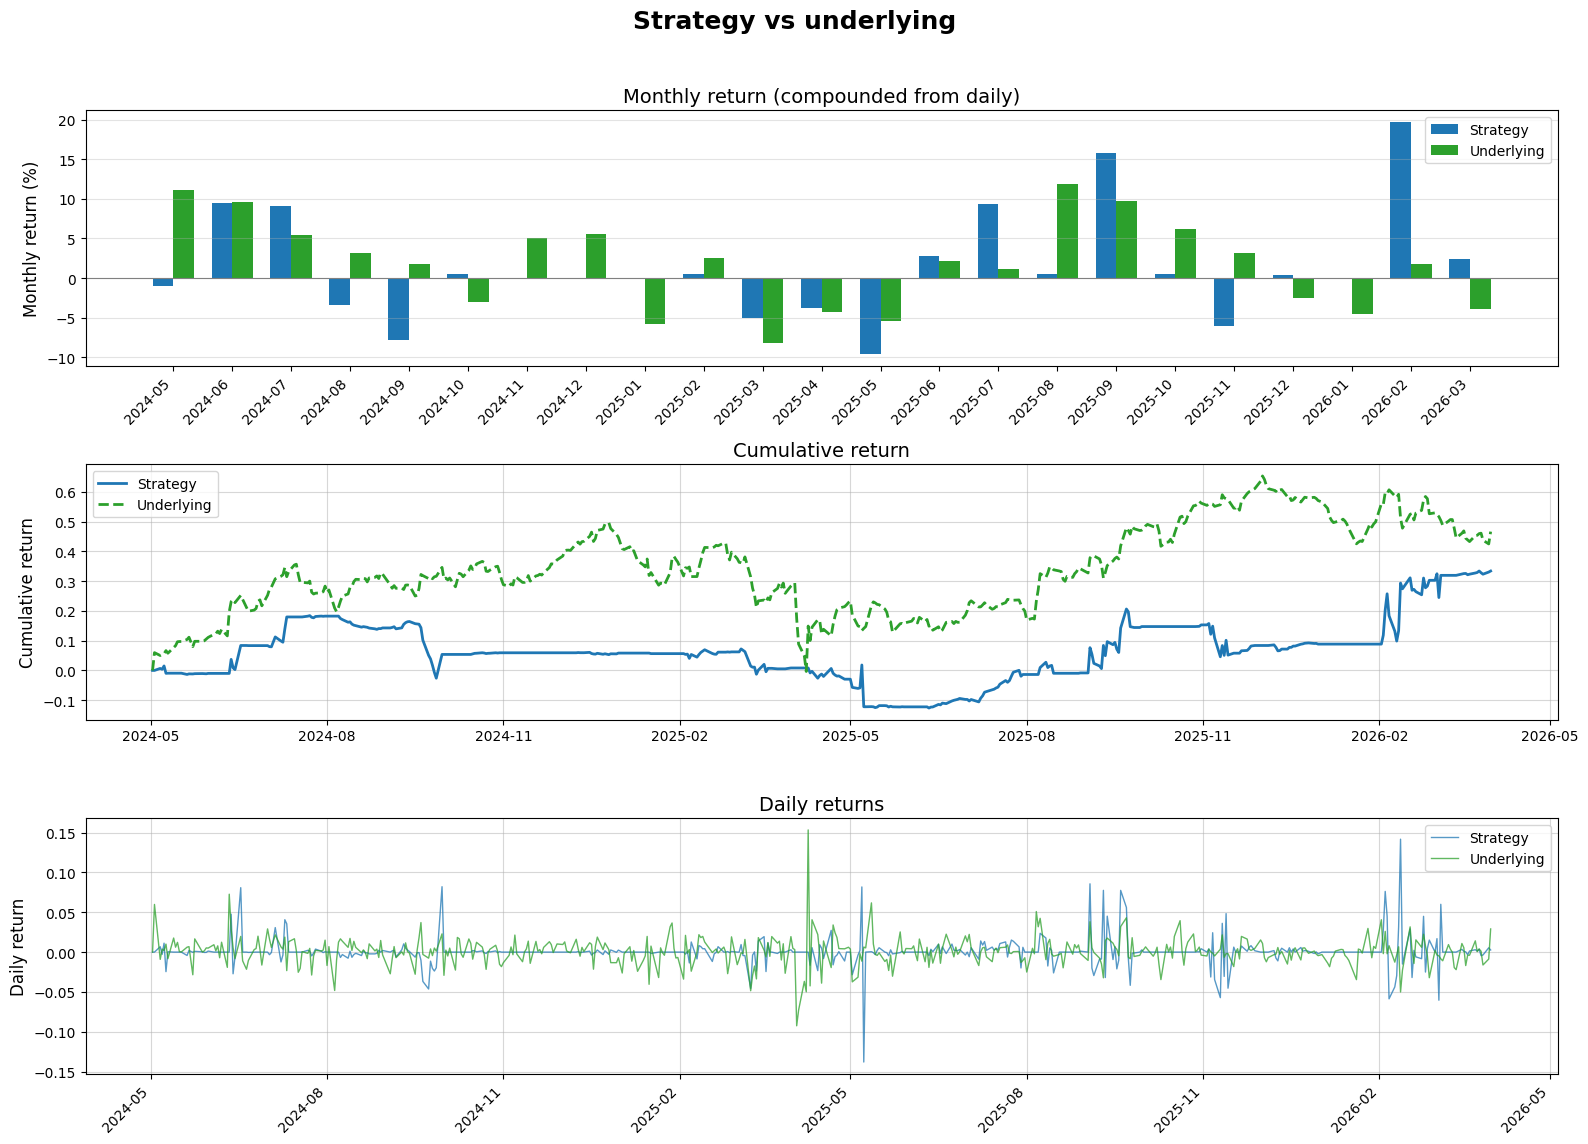

In [12]:
# Annual return = CAGR (compound annual growth rate) over the backtest period
n_trading_days = len(ret_ddh)
annual_return_ddh = (1 + tot_ddh) ** (252 / n_trading_days) - 1 if n_trading_days > 0 else 0.0
annual_return_straddle = (1 + tot_straddle) ** (252 / n_trading_days) - 1 if n_trading_days > 0 else 0.0

# Display in a formatted table
metrics_df = pd.DataFrame({
    'Strategy': ['Delta-Hedged', 'Pure Straddle'],
    'Sharpe Ratio': [sharpe_ddh, sharpe_straddle],
    'Sortino Ratio': [sortino_ddh, sortino_straddle],
    'Annual Return': [f"{annual_return_ddh:.4%}", f"{annual_return_straddle:.4%}"],
    'Annual Volatility': [f"{vol_ddh:.4%}", f"{vol_straddle:.4%}"],
    'Max Drawdown': [f"{dd_ddh:.2%}", f"{dd_straddle:.2%}"],
    'Calmar Ratio': [calmar_ddh, calmar_straddle]
})
print("\nRisk-Return Summary:")
print(metrics_df.to_string(index=False))
print()

# Month-end compounded return from daily series (strategy vs underlying)
_daily_cmp = (
    pd.DataFrame(
        {
            "Date": pd.to_datetime(date_idx),
            "strat": np.asarray(ret_ddh, dtype=float),
            "und": np.asarray(underlying_returns, dtype=float),
        }
    )
    .set_index("Date")
    .sort_index()
)
_m = _daily_cmp.resample("ME")
monthly_strat = _m["strat"].apply(lambda s: (1.0 + s).prod() - 1.0)
monthly_und = _m["und"].apply(lambda s: (1.0 + s).prod() - 1.0)
_monthly = pd.DataFrame({"strat": monthly_strat, "und": monthly_und}).dropna(how="all")

fig, axs = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
fig.suptitle('Strategy vs underlying', fontsize=18, fontweight='bold')

# 1. Monthly return (%): strategy vs underlying
_mx = np.arange(len(_monthly))
_w = 0.35
axs[0].bar(_mx - _w / 2, _monthly["strat"].values * 100.0, width=_w, label="Strategy", color="tab:blue")
axs[0].bar(_mx + _w / 2, _monthly["und"].values * 100.0, width=_w, label="Underlying", color="tab:green")
axs[0].set_xticks(_mx)
axs[0].set_xticklabels([d.strftime("%Y-%m") for d in _monthly.index], rotation=45, ha="right")
axs[0].set_ylabel("Monthly return (%)", fontsize=12)
axs[0].set_title("Monthly return (compounded from daily)", fontsize=14)
axs[0].axhline(0.0, color="gray", linewidth=0.8)
axs[0].grid(True, alpha=0.35, axis="y")
axs[0].legend()

# 2. Cumulative return: strategy vs underlying
axs[1].plot(date_idx, cum_ddh, label="Strategy", color="tab:blue", linewidth=2)
axs[1].plot(date_idx, cum_underlying, label="Underlying", color="tab:green", linewidth=2, linestyle="--")
axs[1].set_ylabel("Cumulative return", fontsize=12)
axs[1].set_title("Cumulative return", fontsize=14)
axs[1].grid(True, alpha=0.5)
axs[1].legend()

# 3. Daily returns
axs[2].plot(date_idx, ret_ddh, label="Strategy", color="tab:blue", alpha=0.75, linewidth=1)
axs[2].plot(date_idx, underlying_returns, label="Underlying", color="tab:green", alpha=0.75, linewidth=1)
axs[2].set_ylabel("Daily return", fontsize=12)
axs[2].set_title("Daily returns", fontsize=14)
axs[2].grid(True, alpha=0.5)
axs[2].legend()

# Date ticks on time-series panels only (monthly panel uses its own labels)
for ax in (axs[1], axs[2]):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axs[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# VRP plot (interactive: zoom, pan, scroll)
import plotly.graph_objects as go
vrp_mean = underlying_df['VRP_mean'].values
vrp = underlying_df['VRP'].values
vrp_std = underlying_df['VRP_std'].values
th = vrp_plot_threshold
x_dates = date_idx.tolist()
fig_vrp = go.Figure()
fig_vrp.add_trace(go.Scatter(x=x_dates, y=vrp_mean, mode='lines', name='VRP_mean', line=dict(color='green', width=1.5)))
fig_vrp.add_trace(go.Scatter(x=x_dates, y=vrp, mode='lines', name='VRP', line=dict(color='red', width=2)))
fig_vrp.add_trace(go.Scatter(x=x_dates, y=vrp_mean + th * vrp_std, mode='lines', name=f'VRP_mean + {th}×VRP_std', line=dict(color='blue', width=1)))
fig_vrp.add_trace(go.Scatter(x=x_dates, y=vrp_mean - th * vrp_std, mode='lines', name=f'VRP_mean - {th}×VRP_std', line=dict(color='blue', width=1)))
vrp_series = pd.Series(vrp, index=pd.to_datetime(date_idx))
y_long = vrp_series.reindex(pd.to_datetime(dates_long_ddh)).values
y_short = vrp_series.reindex(pd.to_datetime(dates_short_ddh)).values
y_close = vrp_series.reindex(pd.to_datetime(dates_close_ddh)).values
y_rehedge = vrp_series.reindex(pd.to_datetime(dates_rehedge_ddh)).values
fig_vrp.add_trace(go.Scatter(x=dates_long_ddh, y=y_long, mode='markers', name='Long', marker=dict(symbol='triangle-up', size=12, color='purple')))
fig_vrp.add_trace(go.Scatter(x=dates_short_ddh, y=y_short, mode='markers', name='Short', marker=dict(symbol='triangle-down', size=12, color='purple')))
fig_vrp.add_trace(go.Scatter(x=dates_close_ddh, y=y_close, mode='markers', name='Close', marker=dict(symbol='x', size=12, color='purple')))
fig_vrp.add_trace(go.Scatter(x=dates_rehedge_ddh, y=y_rehedge, mode='markers', name='Rehedge', marker=dict(symbol='circle', size=12, color='purple')))
fig_vrp.update_layout(
    title=dict(text='VRP Mean, VRP and threshold band', y=0.98, yanchor='top'),
    margin=dict(t=100, b=60, l=60, r=40),
    xaxis_title='Date',
    yaxis_title='VRP / VRP_mean',
    height=800,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig_vrp.show()

# ==========================
# Summary Table
# ==========================
summary_df = pd.DataFrame({
    'Metric': ['Final NAV', 'Total Return', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio'],
    'Delta-Hedged': [
        f"${nav_ddh_arr[-1]:,.0f}",
        f"{tot_ddh:.2%}",
        f"{sharpe_ddh:.2f}",
        f"{sortino_ddh:.2f}",
        f"{dd_ddh:.2%}",
        f"{calmar_ddh:.2f}"
    ],
    'Pure Straddle': [
        f"${nav_straddle_arr[-1]:,.0f}",
        f"{tot_straddle:.2%}",
        f"{sharpe_straddle:.2f}",
        f"{sortino_straddle:.2f}",
        f"{dd_straddle:.2%}",
        f"{calmar_straddle:.2f}"
    ]
})

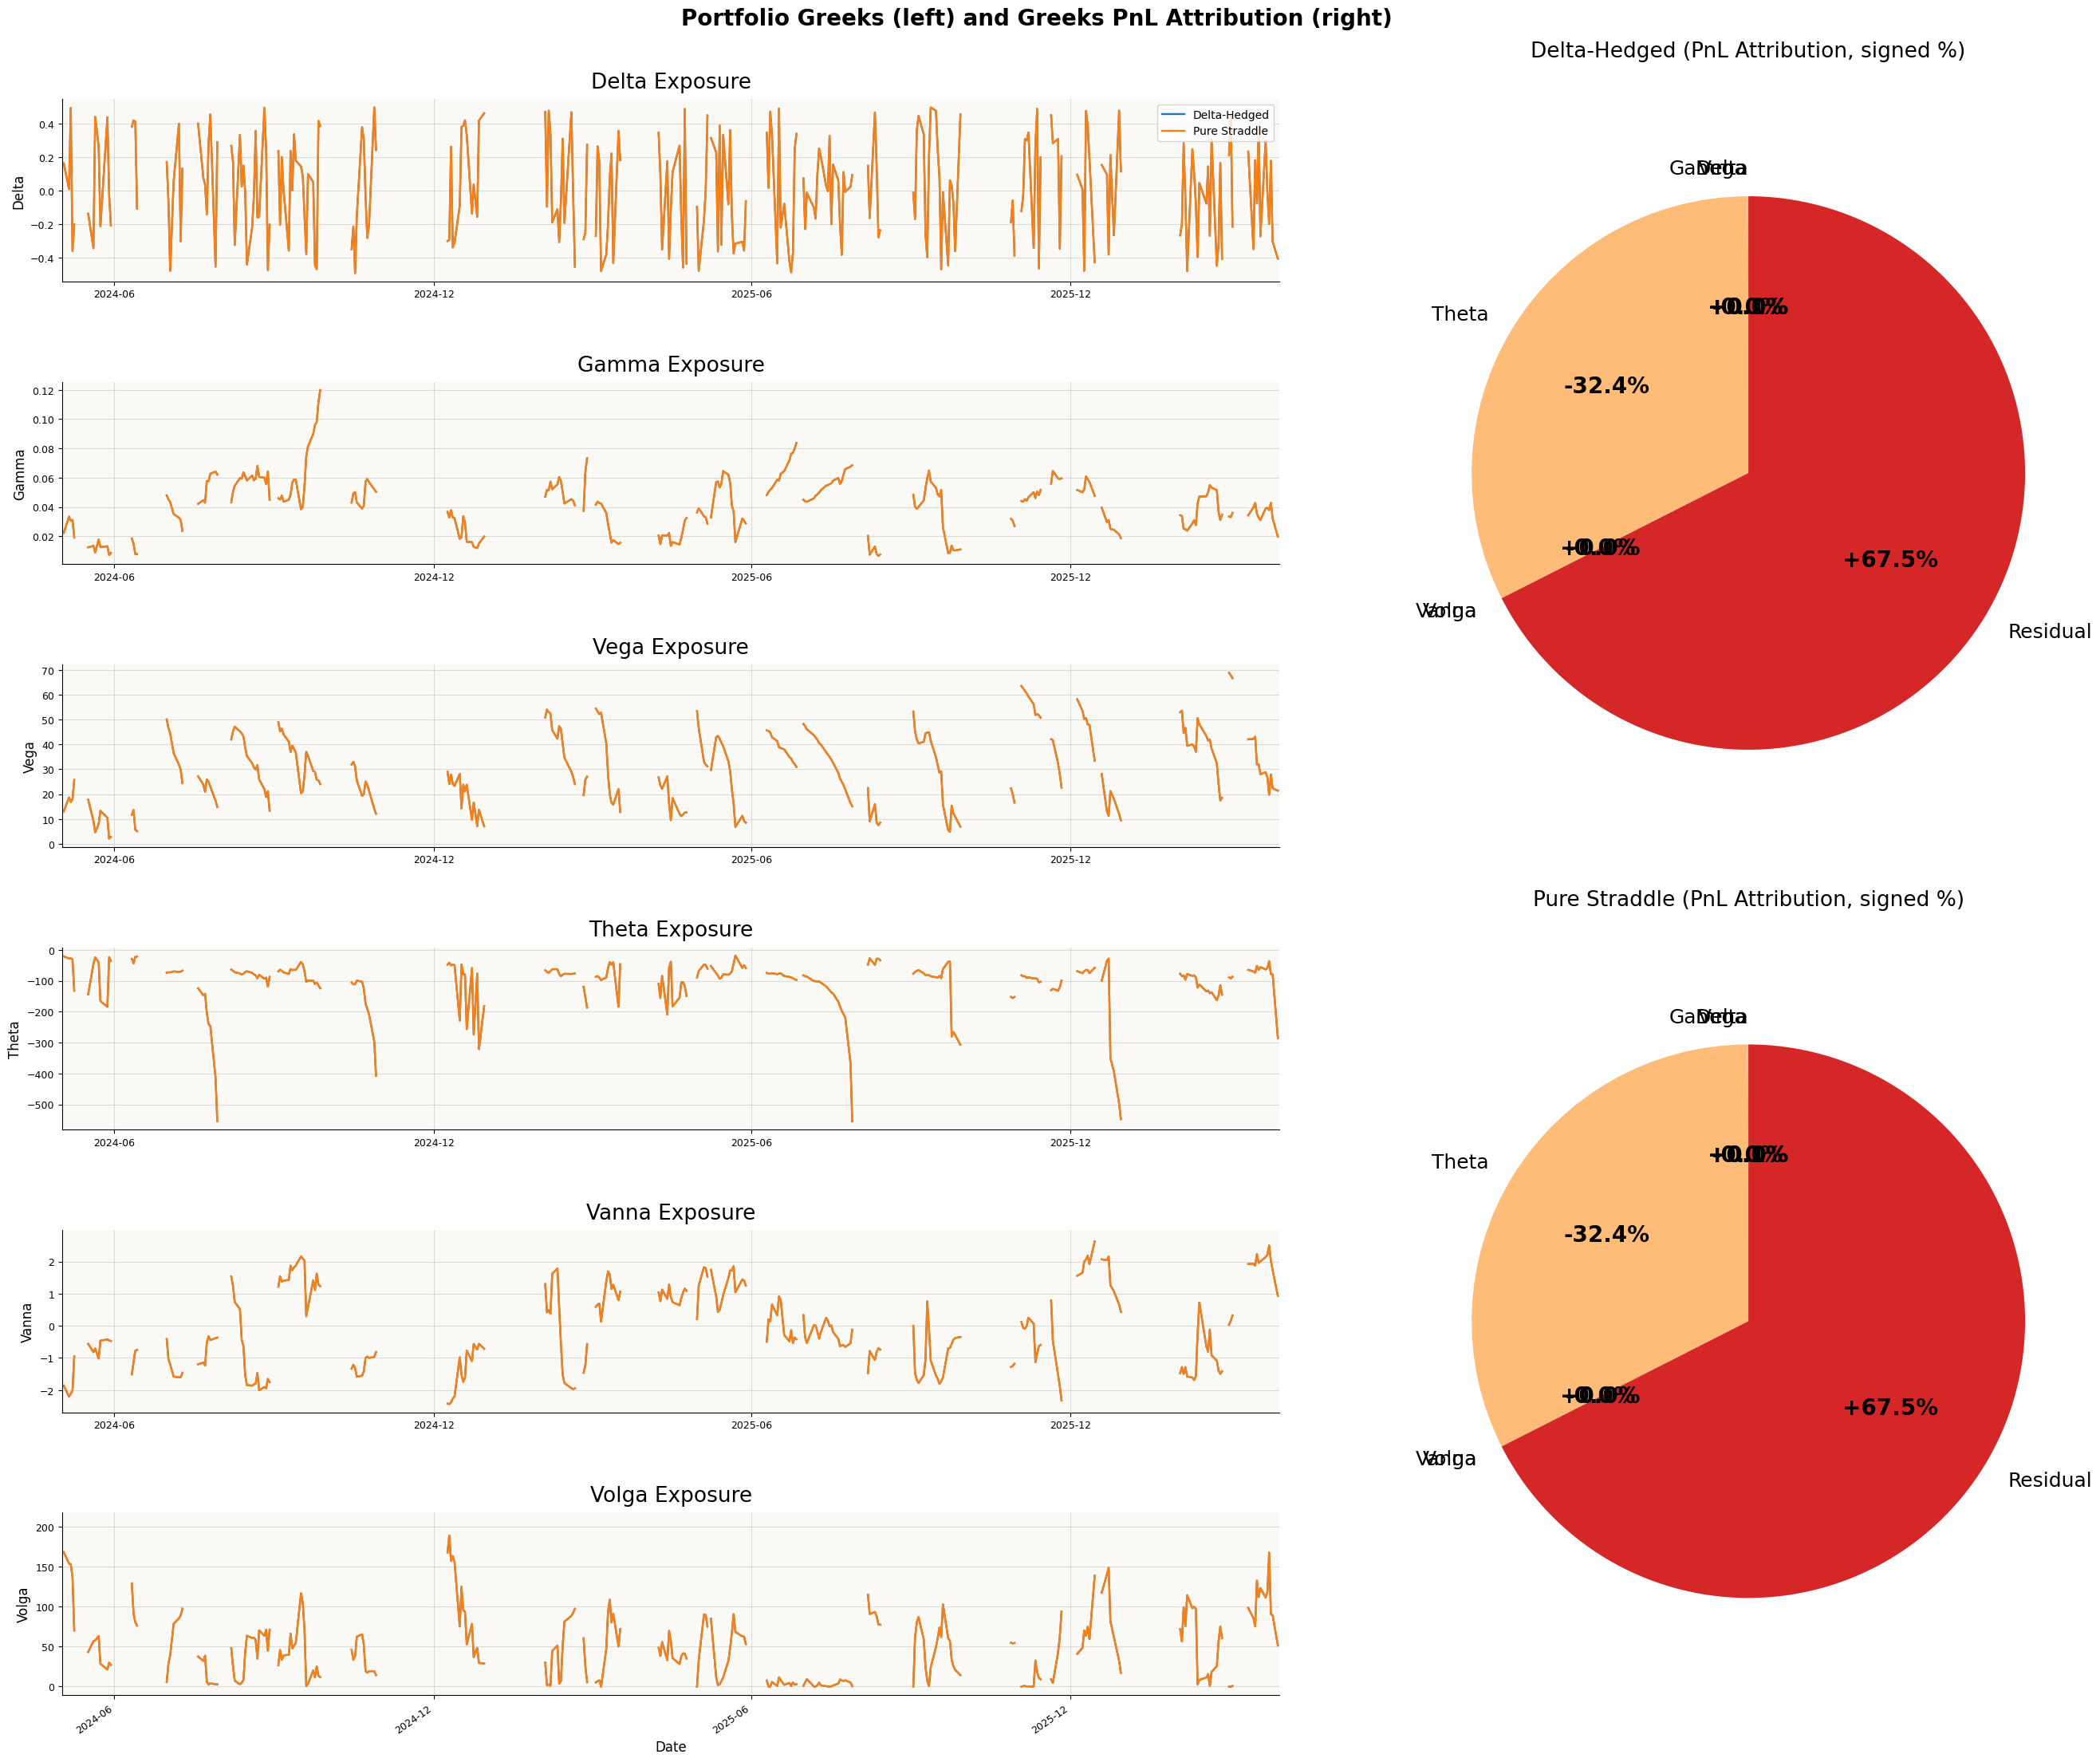

In [13]:
## Plot Portfolio Greeks

import matplotlib.gridspec as gridspec

# Convert date_idx to numpy array for robust indexing
date_idx_arr = np.array(date_idx)

# Use original overall size
fig = plt.figure(figsize=(26, 23))
# Change width_ratios to 2/3 (lines) vs 1/3 (pies)
gs = gridspec.GridSpec(
    6, 2,
    width_ratios=[2, 1],   # 2/3 for lines, 1/3 for pies
    wspace=0.18,
    hspace=0.55
)

# Left column: line plots
axs_lines = [fig.add_subplot(gs[i, 0]) for i in range(6)]
# Right column: TWO pie charts, explicitly same row span
ax_pie_top    = fig.add_subplot(gs[0:3, 1])
ax_pie_bottom = fig.add_subplot(gs[3:6, 1])

# The overall title (top)
fig.suptitle('Portfolio Greeks (left) and Greeks PnL Attribution (right)', fontsize=20, fontweight='bold', y=0.99)

# Match pie chart title font size for subtitles
pie_title_fontsize = 19

greeks_ddh = [delta_ddh, gamma_ddh, vega_ddh, theta_ddh, vanna_ddh, volga_ddh]
greeks_straddle = [delta_straddle, gamma_straddle, vega_straddle, theta_straddle, vanna_straddle, volga_straddle]
titles = ['Delta', 'Gamma', 'Vega', 'Theta', 'Vanna', 'Volga']

for i, (g_ddh, g_str, t) in enumerate(zip(greeks_ddh, greeks_straddle, titles)):
    axs_lines[i].plot(date_idx_arr, g_ddh, label='Delta-Hedged', color='tab:blue', linewidth=1.7)
    axs_lines[i].plot(date_idx_arr, g_str, label='Pure Straddle', color='tab:orange', linewidth=1.7)
    axs_lines[i].set_ylabel(t, fontsize=12)
    axs_lines[i].set_title(f'{t} Exposure', fontsize=pie_title_fontsize, pad=10)
    axs_lines[i].grid(True, alpha=0.4)
    if i == 0:
        axs_lines[i].legend(fontsize=10, loc='upper right')
    if i < 5:
        axs_lines[i].set_xticklabels([])
    else:
        axs_lines[i].set_xlabel('Date', fontsize=12)
        axs_lines[i].tick_params(axis='x', labelrotation=35)
    axs_lines[i].tick_params(axis='y', labelsize=9)
    axs_lines[i].tick_params(axis='x', labelsize=9)
    axs_lines[i].set_xlim([date_idx_arr[0], date_idx_arr[-1]])
    axs_lines[i].set_facecolor("#faf9f6")
    axs_lines[i].spines[['right', 'top']].set_visible(False)
    axs_lines[i].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axs_lines[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.setp(axs_lines[-1].xaxis.get_majorticklabels(), rotation=35, ha='right')

# Prepare Greeks PnL attribution and pie data
S = underlying_df['Close'].values
sigma_raw = underlying_df['IV'].astype(float).values
if np.nanmax(np.abs(sigma_raw)) > 1.0:
    sigma_raw = sigma_raw / 100.0  # IV was in percent
sigma = pd.Series(sigma_raw).ffill().bfill().values
dS = np.diff(S, prepend=S[0])
dS[0] = 0.0
dSigma = np.diff(sigma, prepend=sigma[0])
dSigma[0] = 0.0
dt_theta = 1.0

def greeks_pnl_attribution(nav, delta, gamma, vega, theta, vanna, volga, active_mask=None, option_value=None):
    actual_arr = np.asarray(nav, dtype=float)
    actual_arr = np.nan_to_num(actual_arr, nan=0.0)
    d_nav = np.diff(actual_arr, prepend=actual_arr[0])
    d_nav[0] = 0.0
    delta_prev = np.roll(np.nan_to_num(delta, nan=0.0), 1).astype(float)
    gamma_prev = np.roll(np.nan_to_num(gamma, nan=0.0), 1).astype(float)
    vega_prev = np.roll(np.nan_to_num(vega, nan=0.0), 1).astype(float)
    theta_prev = np.roll(np.nan_to_num(theta, nan=0.0), 1).astype(float)
    vanna_prev = np.roll(np.nan_to_num(vanna, nan=0.0), 1).astype(float)
    volga_prev = np.roll(np.nan_to_num(volga, nan=0.0), 1).astype(float)
    delta_prev[0] = gamma_prev[0] = vega_prev[0] = theta_prev[0] = vanna_prev[0] = volga_prev[0] = 0.0

    pnl_delta = delta_prev * dS
    pnl_gamma = 0.5 * gamma_prev * (dS ** 2)
    pnl_vega = vega_prev * dSigma
    pnl_theta = theta_prev * dt_theta
    pnl_vanna = vanna_prev * dS * dSigma
    pnl_volga = 0.5 * volga_prev * (dSigma ** 2)

    approx = pnl_delta + pnl_gamma + pnl_vega + pnl_theta + pnl_vanna + pnl_volga
    residual = d_nav - approx

    if active_mask is not None:
        active_prev = np.roll(active_mask.astype(bool), 1)
        active_prev[0] = False
        pnl_delta = np.where(active_prev, pnl_delta, 0.0)
        pnl_gamma = np.where(active_prev, pnl_gamma, 0.0)
        pnl_vega = np.where(active_prev, pnl_vega, 0.0)
        pnl_theta = np.where(active_prev, pnl_theta, 0.0)
        pnl_vanna = np.where(active_prev, pnl_vanna, 0.0)
        pnl_volga = np.where(active_prev, pnl_volga, 0.0)
        residual = np.where(active_prev, residual, 0.0)

    return {
        'pnl_delta': pnl_delta,
        'pnl_gamma': pnl_gamma,
        'pnl_vega': pnl_vega,
        'pnl_theta': pnl_theta,
        'pnl_vanna': pnl_vanna,
        'pnl_volga': pnl_volga,
        'pnl_residual': residual,
        'cum_delta': np.cumsum(pnl_delta),
        'cum_gamma': np.cumsum(pnl_gamma),
        'cum_vega': np.cumsum(pnl_vega),
        'cum_theta': np.cumsum(pnl_theta),
        'cum_vanna': np.cumsum(pnl_vanna),
        'cum_volga': np.cumsum(pnl_volga),
        'cum_residual': np.cumsum(residual),
    }

active_ddh = np.asarray(opt_ddh) != 0
active_straddle = np.asarray(opt_straddle) != 0
attr_ddh = greeks_pnl_attribution(nav_ddh_arr, delta_ddh, gamma_ddh, vega_ddh, theta_ddh, vanna_ddh, volga_ddh, active_mask=active_ddh)
attr_straddle = greeks_pnl_attribution(nav_straddle_arr, delta_straddle, gamma_straddle, vega_straddle, theta_straddle, vanna_straddle, volga_straddle, active_mask=active_straddle)

labels = ['Delta', 'Gamma', 'Vega', 'Theta', 'Vanna', 'Volga', 'Residual']
tot_ddh = np.nan_to_num([
    float(np.nansum(attr_ddh['pnl_delta'])),
    float(np.nansum(attr_ddh['pnl_gamma'])),
    float(np.nansum(attr_ddh['pnl_vega'])),
    float(np.nansum(attr_ddh['pnl_theta'])),
    float(np.nansum(attr_ddh['pnl_vanna'])),
    float(np.nansum(attr_ddh['pnl_volga'])),
    float(np.nansum(attr_ddh['pnl_residual'])),
], nan=0.0)
tot_straddle = np.nan_to_num([
    float(np.nansum(attr_straddle['pnl_delta'])),
    float(np.nansum(attr_straddle['pnl_gamma'])),
    float(np.nansum(attr_straddle['pnl_vega'])),
    float(np.nansum(attr_straddle['pnl_theta'])),
    float(np.nansum(attr_straddle['pnl_vanna'])),
    float(np.nansum(attr_straddle['pnl_volga'])),
    float(np.nansum(attr_straddle['pnl_residual'])),
], nan=0.0)

# Pie chart helper function - pies get the same radius and formatting
def make_pie(ax, vals, lbls, title):
    colors = plt.get_cmap('tab20').colors

    total_sum = np.sum(np.abs(vals))
    # Calculate actual signed pct for correct signed display
    pct_vals = (vals / total_sum) * 100 if total_sum != 0 else np.zeros_like(vals)

    # Custom autopct function to print percentages with sign
    def autopct_with_sign(pct):
        # pct param is always positive because of np.abs() in pie
        # We need to find the correct index
        # This lambda gets called in order, so enumerate all nonzero indices
        # We can abuse closure by adding a counter as attribute
        if not hasattr(autopct_with_sign, "i"):
            autopct_with_sign.i = 0
        i = autopct_with_sign.i
        if i < len(pct_vals):
            pct_val = pct_vals[i]
        else:
            pct_val = 0.0
        autopct_with_sign.i += 1
        # Show signed, 1 decimal
        if np.abs(pct) > 0:
            return f'{pct_val:+.1f}%'
        else:
            return ''

    # Reset the function counter before each pie
    autopct_with_sign.i = 0

    wedges, texts, autotexts = ax.pie(
        np.abs(vals),
        labels=lbls,
        startangle=90,
        colors=colors,
        autopct=autopct_with_sign,
        textprops={'fontsize': 19},
        radius=1.08 # both pies use the same, calibrated to fit comfortably
    )
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(20)
    for text in texts:
        text.set_fontsize(18)
    ax.set_title(title, fontsize=19, pad=38)
    ax.axis('equal')  # Keep pies circular

# Two pies, identical grid row span and explicit same radius
make_pie(ax_pie_top, tot_ddh, labels, "Delta-Hedged (PnL Attribution, signed %)")
make_pie(ax_pie_bottom, tot_straddle, labels, "Pure Straddle (PnL Attribution, signed %)")

plt.subplots_adjust(left=0.03, right=0.99, top=0.94, bottom=0.07, wspace=0.15, hspace=0.56)
plt.show()
